In [914]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [915]:
import jax
# JAX_DEBUG_NANS=True
# jax.config.update("jax_debug_nans", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings

In [916]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [917]:
print(jax.default_backend())

gpu


In [918]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [919]:
t0, tfinal = 0.0, 5.0

In [920]:
k = 1.0
l = 2.0

In [921]:
#@jax.jit
def newton(A, G, A_0, F_0, G_0, E) :

  F = ((4*E - (A**2/l**2) - ((2*(G**2))/(k**2 + l**2)))*(k**2))

  dF_dA = -(A*(k**2))/(F*(l**2))
  dF_dG = -(2*G*(k**2))/(F*(k**2 + l**2))

  D = (A - A_0)**2 + (F - F_0)**2 + (G - G_0)**2

  H1 = 2*(A - A_0) + 2*(F - F_0)*dF_dA
  H2 = 2*(F - F_0)*dF_dG + 2*(G - G_0)

  H = jnp.array([H1, H2])

  dH1_dA = 2 - (2*(k**2))/(l**2) + ((2*(k**2)*F_0)/(l**2))*((F - (A*dF_dA))/(F**2))
  dH1_dG = -((2*(k**2)*F_0*A)/((F**2)*(l**2)))*dF_dG

  dH2_dA = -((4*(k**2)*F_0*G)/((F**2)*(k**2 + l**2)))*dF_dA
  dH2_dG = -((4*(k**2))/(k**2 + l**2)) + ((4*(k**2)*F_0)/(k**2 + l**2))*((F - (G*dF_dG))/(F**2)) + 2

  J = jnp.array([[dH1_dA, dH1_dG], [dH2_dA, dH2_dG]])

  J = jnp.squeeze(J)
  
  J_inv = jnp.linalg.inv(J)

  return J_inv, H


In [922]:
# @partial(jax.jit, static_argnums=(1,))
def obj_function(x, E_0) :

    # print("SHAPES", x.shape, E_0.shape)
    A, F, G = x
    E = (0.25)*((A**2/l**2) + (F**2/k**2) + (2.*(G**2)/(k**2 + l**2)))
    E_rr = (E-E_0)**2

    print(E_rr)

    return E_rr

In [923]:
# @partial(jax.jit, static_argnums=(1,))
def distance_eq(AFG_vals, E_0_val) :

    delta = 0.95

    E_0_val = E_0_val[0]
    
    # A = A_0*delta
    # F = F_0*delta
    # G = G_0*delta

    result = minimize(obj_function, AFG_vals, args = (E_0_val,), method='BFGS', tol = 1e-5)
    result = result.x
    
    A, F, G = result

    return A, F, G
    

# @partial(jax.jit, static_argnums=(1,))
def find_closest(AFG_vals, E_0_val) :

    return jax.vmap(distance_eq, [0, 0])(AFG_vals, E_0_val)


In [924]:
vals_arr = jnp.array([[3.0, 2.0, 5.8], [6.9, -2.0, -5.8]])
E_arr = jnp.array([3.4, -7.8])

# find_closest(vals_arr, E_arr)


In [925]:
class ClosestPoint(nn.Module):

  E_0: float

  @nn.compact
  def __call__(self, inputs):

    A_final, F_final, G_final = find_closest(inputs, self.E_0)

    return A_final, F_final, G_final

In [926]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [927]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [928]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [929]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [930]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    As = np.random.uniform(0.0, 1.0, size = (N, 1))
    Fs = np.random.uniform(0.0, 1.0, size = (N, 1))
    Gs = np.random.uniform(0.0, 1.0, size = (N, 1)) 
    # Es = (0.25)*((As**2/l**2) + (Fs**2/k**2) + (2.*(Gs**2)/(k**2 + l**2)))
    # Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))
    
    E_points = (0.25)*((As**2/l**2) + (Fs**2/k**2) + (2.*(Gs**2)/(k**2 + l**2)))
    
    sensor_points = np.column_stack((As, Fs, Gs))
    
    return (ode_points, sensor_points, E_points)

In [931]:
(de_points, sensors, E_points) = define_collocation_points([t0, tfinal], 500)
print(de_points.shape, sensors.shape, E_points.shape)

(500, 1) (500, 3) (500, 1)


In [932]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u, E):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:]

    t = jnp.reshape(t, (-1,1))
    E = jnp.reshape(E, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [933]:
@partial(jax.jit, static_argnums=(2,3))
def var_model(t, z, E, component, params):
  return deeponet.apply(params, t, z, E)[component][0]

@partial(jax.jit, static_argnums=(2,3))
def var(t, z, E, component, params):
  return jax.vmap(var_model, [0, 0, None, None, None])(t, z, E, component, params)

@partial(jax.jit, static_argnums=(2,3))
def var_t(t, z, E, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None, None])(t, z, E.any(), component, params)

@jax.jit
def loss(params, t, z, E):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 1.0

  A_val = var(t, z, E, 0, params)
  F_val = var(t, z, E, 1, params)
  G_val = var(t, z, E, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)

  A_t_val = var_t(t, z, E, 0, params)
  F_t_val = var_t(t, z, E, 1, params)
  G_t_val = var_t(t, z, E, 2, params)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)

  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss

  return final_loss

@jax.jit
def train_step(params, pdes, z, E):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z, E)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [934]:
def train_network(params, des, sensors, E_points, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_E = tf.data.Dataset.from_tensor_slices(E_points)
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z, ds_E))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    
    for i in range(epochs):
    
        for (des_batch, z_batch, E_batch) in ds:
        
            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy(), E_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)
        
            epoch_loss[i] += loss
        
        epoch_loss[i] /= batch_size
    
        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [935]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 3), 1.0)
E_init = jnp.full((10, ), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init, E_init)

In [936]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

19920


In [937]:
epochs = 1000
params, loss = train_network(params, de_points, sensors, E_points, epochs)

batch size: 50
Loss in epoch 0: 0.08094030380249023
Loss in epoch 100: 0.0030469772219657897
Loss in epoch 200: 0.0027869200706481935
Loss in epoch 300: 0.0024271856248378756
Loss in epoch 400: 0.0023943620920181276
Loss in epoch 500: 0.0023593805730342866
Loss in epoch 600: 0.00235454723238945
Loss in epoch 700: 0.002290898263454437
Loss in epoch 800: 0.0023832641541957854
Loss in epoch 900: 0.002321120798587799


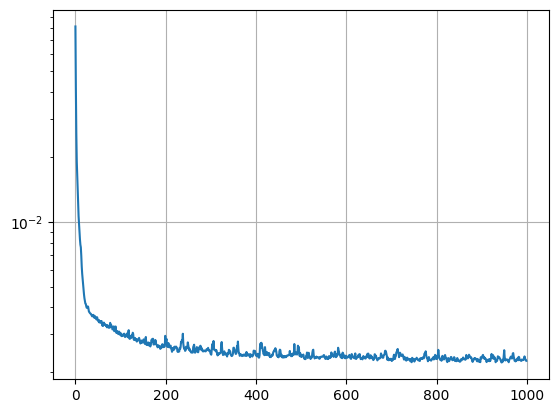

In [938]:
plt.semilogy(loss)
plt.grid()

In [939]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(0.0, 1.0, size=(1,))
F_data = np.random.uniform(0.0, 1.0, size=(1,))
G_data = np.random.uniform(0.0, 1.0, size=(1,))
E_data = (0.25)*((A_data**2/l**2) + (F_data**2/k**2) + (2.*(G_data**2)/(k**2 + l**2)))
# V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, G_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
E = np.repeat(np.expand_dims(E_data, axis=0), len(t), axis=0)
print(z.shape)

(3,)
(500, 3)


In [940]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))

In [947]:
A = jax.vmap(partial(var_model, E = E), [0, 0, None, None])(t, z, 0, params)
F = jax.vmap(var_model, [0, 0, None, None, None])(t, z, E, 1, params)
G = jax.vmap(var_model, [0, 0, None, None, None])(t, z, E, 2, params)

ValueError: Non-hashable static arguments are not supported, as this can lead to unexpected cache-misses. Static argument (index 3) of type <class 'dict'> for function var_model is non-hashable.

In [ ]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [ ]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    print("START", print(type(u)), u.shape)

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]


    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

      
    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A, F, G = ClosestPoint(E_0)([A, F, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [ ]:
#@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

#@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

#@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

#@jax.jit
def Closs(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 0.0
  V_loss_w = 0.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  # print("PARAMS", params)

  A_val = Cvar(t, z, 0, params)
  F_val = Cvar(t, z, 1, params)
  G_val = Cvar(t, z, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = Cvar_t(t, z, 0, params)  
  F_t_val = Cvar_t(t, z, 1, params)
  G_t_val = Cvar_t(t, z, 2, params)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)

  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

#@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

#@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [ ]:
def Ctrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  batch_no = 0

  for i in range(epochs):

    print(i)

    for (des_batch, z_batch) in ds:

      print("BATCH NUMBER", batch_no)

      # if batch_no == 9 :
          
      #     input()

      # print("PARAMS--------------------------------------------------")
      # print(params)
        
      batch_no = batch_no + 1

      loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
        
      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [ ]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [ ]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

In [ ]:
Cparams = copy.deepcopy(params)

In [ ]:
epochs = 100
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

In [ ]:
plt.semilogy(Closs)
plt.grid()

In [ ]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))

In [ ]:
fig = plt.figure()

plt.subplot(1, 4, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 4)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()
